In [1]:
import torch
import pyro

if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
    print("Using MPS GPU")
else:
    device = torch.devicce("cpu")
    print("Using CPU")

Using MPS GPU


/Users/trevorwilliams/github/SRBayesianPyro/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
from pathlib import Path

import seaborn as sns
import pyro.distributions as dist

rootDir = Path().resolve().parents[0]
sys.path.append(str(rootDir))

from rethinking import MAP, precis

## 2.1 The garding of forking data

Bayesian inference is really just counting and comparing of possibilities -> analogy Jorge Luis Borges' short story "The Garding of Forking Paths"

Approach provides a quantitative ranking of hypotheses that is maximally conservative given the assumptions and the data.

### 2.1.1 Counting possibilities

Toy example:
 * Bag with four marbles each of which can be blue or white. 
 * We know there are four marbles but don't know what color they are
 * Possibilities (also called conjectures):
    * 4 white, 1 blue 3 white, 2 blue 2 white, 3 blue 1 white, 4 blue
 * Goal: Find out which conjecture is most plausible given the evidence of pulling three marbles with replacement and seeing: blue, white, blue

Can visualize as a garden of forking paths, with each path being an event. For example, using the conjecture 1 blue 3 white we get


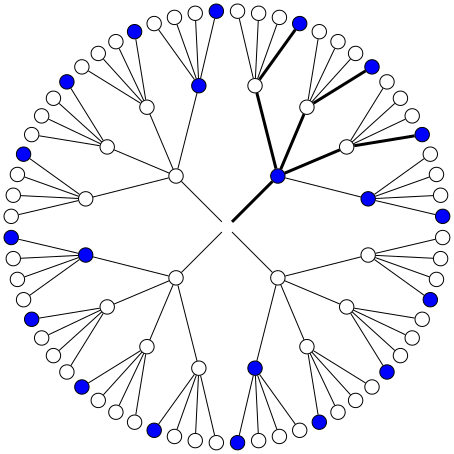

In [3]:
# Forking data with Graphviz

import graphviz

dot = graphviz.Graph('forks',
                     comment='1 Blue 3 White',
                     graph_attr={
                        'rankdir': 'BT',
                        'size': '15,15'
                        },
                     node_attr={
                        'width': '0.2',
                        'height': '0.2',
                        'fixedsize': 'true'},
                    engine='twopi'
                     )

dot.node('A', '', style='invis')
dot.node('B', '', shape='circle', fillcolor='blue', style='filled')
dot.node('C', '', shape='circle', fillcolor='white')
dot.node('D', '', shape='circle', fillcolor='white')
dot.node('E', '', shape='circle', fillcolor='white')

dot.node('F', '', shape='circle', fillcolor='blue', style='filled')
dot.node('G', '', shape='circle', fillcolor='white')
dot.node('H', '', shape='circle', fillcolor='white')
dot.node('I', '', shape='circle', fillcolor='white')

dot.node('J', '', shape='circle', fillcolor='blue', style='filled')
dot.node('K', '', shape='circle', fillcolor='white')
dot.node('L', '', shape='circle', fillcolor='white')
dot.node('M', '', shape='circle', fillcolor='white')

dot.node('N', '', shape='circle', fillcolor='blue', style='filled')
dot.node('O', '', shape='circle', fillcolor='white')
dot.node('P', '', shape='circle', fillcolor='white')
dot.node('Q', '', shape='circle', fillcolor='white')

dot.node('R', '', shape='circle', fillcolor='blue', style='filled')
dot.node('S', '', shape='circle', fillcolor='white')
dot.node('T', '', shape='circle', fillcolor='white')
dot.node('U', '', shape='circle', fillcolor='white')


# Draw 1: A -> blue B (bold), A -> white C/D/E (normal)
dot.edge('A', 'B', penwidth='3')
dot.edges(['AC', 'AD', 'AE'])

# Draw 2: blue B -> white G/H/I (bold), blue B -> blue F (normal)
dot.edge('B', 'F')
dot.edge('B', 'G', penwidth='3')
dot.edge('B', 'H', penwidth='3')
dot.edge('B', 'I', penwidth='3')
dot.edges(['CJ', 'CK', 'CL', 'CM'])
dot.edges(['DN', 'DO', 'DP', 'DQ'])
dot.edges(['ER', 'ES', 'ET', 'EU'])

# Draw 3: white G/H/I -> blue child (bold), all others normal
bold_white_parents = {'G', 'H', 'I'}
for parent in ['F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U']:
    for i in range(4):
        node_id = f'{parent}{i}'
        if i == 0:
            dot.node(node_id, '', shape='circle', fillcolor='blue', style='filled')
        else:
            dot.node(node_id, '', shape='circle', fillcolor='white')
        if parent in bold_white_parents and i == 0:
            dot.edge(parent, node_id, penwidth='3')
        else:
            dot.edge(parent, node_id)

dot

According to the garden of forking data, there are 3 paths (bolded) for a bag containing 1 blue marble and three white marbles to produce the observed data blue-white-blue

if we extend this to the other conjectures we get the following table of ways to produce the data:

In [4]:
import pandas as pd

pd.DataFrame({
    'Conjecture': [
        'WWWW',
        'BWWW',
        'BBWW',
        'BBBW',
        'BBBB'
    ],
    'Ways_to_produce_BWB': [
        '0x4x0=0',
        '1x3x1=3',
        '2x2x2=8',
        '3x1x3=9',
        '4x0x4=0'
    ]
})

,Conjecture,Ways_to_produce_BWB
0,WWWW,0x4x0=0
1,BWWW,1x3x1=3
2,BBWW,2x2x2=8
3,BBBW,3x1x3=9
4,BBBB,4x0x4=0


### 2.1.2 Combining other information

We may have additional information about the relative plausibility of each conjecture. To combine this data to update the plausibilities you just multiply the counts.

We can use the data above to define a *prior* - in this case it states that BBWW and BBBW are about three times more plausible than BWWW (8 and 9 vs 3). Say we draw another marble from the bag so we now have BWBB. We can now update our prior counts (0,3,8,9,0) and update them in light of the new data as shown in the table below (provided the new draw is independent of the otheres)

In [5]:
pd.DataFrame({
    'Conjecture': [
        'WWWW',
        'BWWW',
        'BBWW',
        'BBBW',
        'BBBB'
    ],
    'Ways_to_produce_B': [
        0, 1, 2, 3, 4
    ],
    'Prior_counts': [
        0, 3, 8, 9, 0
    ],
    'New_count': [
        '0x0=0',
        '1x3=3',
        '2x8=16',
        '3x9=27',
        '0x4=0'
    ]
})

,Conjecture,Ways_to_produce_B,Prior_counts,New_count
0,WWWW,0,0,0x0=0
1,BWWW,1,3,1x3=3
2,BBWW,2,8,2x8=16
3,BBBW,3,9,3x9=27
4,BBBB,4,0,0x4=0


In other words:
 1. when we have previous information suggesting there are $W_{prior}$ ways for a conjecture to produce a previous observation $D_{prior}$ 
 2. And we acquire new observations $D_{new}$ that the same conjecture can produce in $W_{new}$ ways
 3. Then the number of ways the conjecture can account for both $D_{prior}$ as well as $D_{new}$ is just the produce $W_{prior} * W_{new}$

Multiplication is just a shortcut to count up all the paths through the garden of forking data

### 2.1.3 From counts to probability

We can't always depend on counts though, so we typically use the language of probability. We can define the updated plausibility of each cpossible composition of the bag, after seeing the data, as:

$$ \text{plausibility of } BWWW \text{ after seeing } BWB \propto \text{ways } BWWW \text{can produce } BWB * \text{prior plausibility } BWWW $$

To frame it in probability terms it will be helpful to define $p$ as the proportion of marbles that are blue. In other words

$$ \text{plausibility of } p \text{ after } D_{new} \propto \text{ways } p \text{ can produce } D_{new} * \text{ prior plausibility of } p $$

Finally, to convert to probability you standardizing the plausibilities by dividing by the sum of all products:

$$ \text{plausibility of } p \text{ after } D_{new} = \frac{\text{ways } p \text{ can produce } D_{new} * \text{ prior plausibility } p}{\text{sum of products}} $$

in table form:

In [6]:
pd.DataFrame({
    'Possible composition': [
        'WWWW',
        'BWWW',
        'BBWW',
        'BBBW',
        'BBBB',
    ],
    'p': [
        0, 0.25, 0.5, 0.75, 1
    ],
    'Ways to produce data': [
        0, 3, 8, 9, 0
    ],
    'Plausibility': [
        0, 0.15, 0.40, 0.45, 0
    ]
})

,Possible composition,p,Ways to produce data,Plausibility
0,WWWW,0.00,0,0.00
1,BWWW,0.25,3,0.15
2,BBWW,0.50,8,0.40
3,BBBW,0.75,9,0.45
4,BBBB,1.00,0,0.00


You can quickly compute these plausibilities in python

In [7]:
# code 2.1
ways = torch.tensor([0., 3, 8, 9, 0])
ways / ways.sum()

tensor([0.0000, 0.1500, 0.4000, 0.4500, 0.0000])

In terms of probability theory:
 * A conjectured proportion of blue marbles, $p$, is usually called a **PARAMETER** value.
 * The relative number of ways that a value $p$ can produce the data is usaully called a **LIKELIHOOD**. It is derived by enumerating all the possible data sequences that could have happened and then eliminating those sequences inconsistent with the data
 * The prior plausibility of any specific $p$ is usally called the **PRIOR PROBABILITY**
 * The new, updated plausibility of any specific $p$ is usually called the **POSTERIOR PROBABILITY**

 ## 2.2 Building a model

 We will build a statistical model using the toy example of tossing a globe to estimate the proportion of the earth that is water. The proceedure to collect data is to toss the globe into the air, catching it, and taking note of whether your right index finger lands on water or on land. For this example we will be working with the follow data sequence: W L W W W L W L W where W indicates water and L indicates land.

 Designing a simple Bayesian model benefits from the following design loop with three steps:

  1. Data story: Motivate the model by narrating how the data might arise
  2. Update: Educate your model by feeding it the data
  3. Evaluate: All statistical models require supervision, leading to model revision

### 2.2.1 A data story

Story may be:
 * Descriptive
 * Causal

Must be complete in order to specify an algorithm for simulating new data. 

Try to explain how each pice of data is born -> means descibing aspects of the underlying reality as well as the sampling process.

In the case of our globe tossing example:

 1. The true proportion of water covering the globe is $p$
 2. A single toss of the globe has a probability $p$ of producing a water (W) observation. It has a probability of $1-p$ of producing a land (L) observation.
 3. Each toss of the globe is independent of the others

### 2.2.2 Bayesian Updating

A Bayesian model begins with one set of plausibilities assigned to each possibility (conjecture). These are the prior plausibilties. Then it updates them in light of the data, to produce the posterior plausibilities. This process is called Bayesian updating. (See figure 2.5 for example with globe tossing model)

### 2.2.3 Evaluate

Worth keeping in mind two cautious principles:

1. The models certainty is no guarantee that the model is a good one. Inferences are conditional on the model.
2. It is important to supervise and critique your model's work. When something is irrelevant to the machine (like data order), it won't affect the inference directly, but it may affect it indirectly because the data will depend upon order.

Goal is not to check that the model is true (since it is not) but rather to check the model's adequacy for some purpose such as prediction, comprehension, measurement, etc.

## 2.3 Components of the model

The usual way to build a statistical model involves choosing distributions and devices that represent the relative number of ways things can happen -> nothing more than naming all of the variables and defining each.

### 2.3.1 Variables

Variables include things we wish to infer, such as proportions and rates, as well as things we might observe, the data. In our globe tossing model there are three variables

1. The proportion of water $p$ (our target of inference). Unobserved variables like this are usually called **PARAMETERS**
2. The counts of water (W)
3. The counts of land (L). Both W and L are observed variables. the sume of these two variables is the number of globe tosses: $N = W + L$

### 2.3.2 Definitions

Need to:
 * For each possible value of the unobserved variables (like $p$) we need to define the relative number of ways (the probability) that the values of each observed variable could arise. 
 * Also need to define the prior plausibility for each value each unobserved variable could take.


#### 2.3.2.1 Observed variables

For $W$ and $L$ we define how plausibile any combination of $W$ and $L$ would be for a specific value of $p$. 

To do so we use a mathematical function -> a distribution function assigned to an observed variable is usually called the **LIKELIHOOD**

With our data story and the assumptions (1) every toss is independent of the other tosses and (2) the probability of $W$ is the same on every toss we can use the *binomial distribution* to calculate the likelihood. This function for our example is:

$$ \text{Pr}(W,L|p) = \frac{(W + L)!}{W!L!}p^{W}(1-p)^L $$

To calculate the likelihood for any value of $p$ using Pyro you do the following:

In [8]:
# Code 2.2
dist.Binomial(total_count=9, probs=0.5).log_prob(torch.tensor(6.)).exp()

tensor(0.1641)

This number is the relative number of ways to get six water, holding $p$ at 0.5 and $N = W + L$ at nine

#### 2.3.2.2 Unobserved variables

We still need to define unobserved variables (parameters). In statistical modeling many of the most common questions we ask about data are answered directly by parameters. e.g. What is the average difference between treatment groups?, Does the effect of treatment depend upon a covariate?

For every parameter in you Bayesian machine you must provide a distribution of prior plasuibility, its **PRIOR**

Priors are both engineering assumptions, to help the model learn, and scientific assumptions, chosen to reflect what we know about a phenomenonq

### 2.3.3 A model is born

We can write our model statistically like:

$$ W \sim \text{Binomial}(N,p) $$

Where $N = W + L$. Our prior is then

$$ p \sim \text{Uniform}(0, 1) $$

## 2.4 Making the model go

Once you have named all the variables and chosen definitions for each, a Bayesian model can update all of the prior distributions to their purely logical consequences: the **POSTERIOR DISTRIBUTION**

For every unique combination of data, likelihood, parameters, and prior, there is a unique posterior distribution. It contains the relative plausibility of different parameeter values conditional on the data and model. $\text{ Pr}(p|W,L)$

### 2.4.1 Bayes' theorem

The mathematical definition of the posterior distribution arises from **BAYES' THERORM** 

A quick derivation using the globe tossing model

Joint probability of teh data $W$ and $L$ and any particular value of $p$ is

$$ \text{Pr}(W,L,p) = \text{Pr}(W, L|p)\text{Pr}(p) $$

which is just saying that the probability of $W$, $L$, and $p$ is the product of $\text{Pr}(W,L|p)$ and the prior probability $\text{Pr}(p)$. It is just as true that

$$ \text{PR}(W,L,p)=\text{Pr}(p|W,L)\text{Pr}(W,L) $$

which just reverses the probability that is conditional. The two statements are like saying the probability of rain and cold on the same day is equal to the probability that it is raining when its cold times the probability it is cold OR the probablity that it is cold when its raining times the probability that it is raining. Since both sides equal the same thing you can set them equal to each other and solve for $\text{Pr}(p|W,L)$ which is the posterior distribution:

$$ \text{Pr}(p|W,L) = \frac{\text{Pr}(W,L|p)\text{Pr}(p)}{\text{Pr}(W, L)} $$

Where $\text{Pr}(W,L)$ is the *average probability of the data* (also called evidence or average likelihood or marginal likelihood). Mathematically it is:

$$ \text{Pr}(W,L) = \text{E}(\text{Pr}(W,L|p)) = \int \text{Pr}(W,L|p)\text{Pr}(p)dp $$

The average probability in the denominator just standardizes teh counts so they sum to one

### 2.4.2 Motors

At the heart of a Bayesian model is a motor that *conditions* the prior on the data. In many instances, the model cannot be conditioned formally (i.e. average probability of the data cannot be computed numerically). 

There is a need for various numerical technics that can approximate the mathematics of Bayes' theroem. This book explores three:

1. Grid approximation
2. Quadratic approximation
3. Markov chain Monte Carlo (MCMC)

### 2.4.3 Grid approximation

While most parameters are *continuous* we can approximate the posterior distribution by considering only a finite grid of parameter values. The recipe:

 1. Define the grid. This means you decide how many points to use in estimating the posterior, and then you make a list of the parameter values on the grid
 2. Compute teh value of the prior at each parameter value on the grid.
 3. Compute the likelihood at each parameter value
 4. Computed the unstandardized posterior at each parameter value, by multiplying the prior by the likelihood
 5. Finally, standardize the posterior, by dividing each value by the sum of all values

 Here is some code to do it in python:

In [9]:
# Code 2.3

#define grid
p_grid = torch.linspace(start=0, end=1, steps=20)

# define prior
prior = torch.tensor(1.).repeat(20)

# Compute the likelihood at each value in the grid
likelihood = dist.Binomial(total_count=9, probs=p_grid).log_prob(torch.tensor(6.)).exp()

# Compute product of likelihood and prior
unstd_posterior = likelihood * prior

# standardize the posterior, so it sums to 1
posterior = unstd_posterior / unstd_posterior.sum()

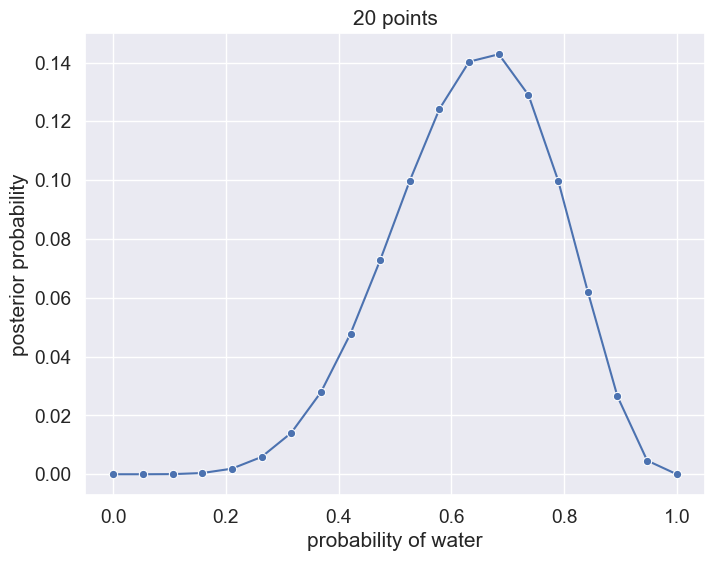

In [10]:
# Code 2.4

ax = sns.lineplot(x=p_grid, y=posterior, marker="o")
ax.set(xlabel="probability of water", ylabel="posterior probability",
       title="20 points");

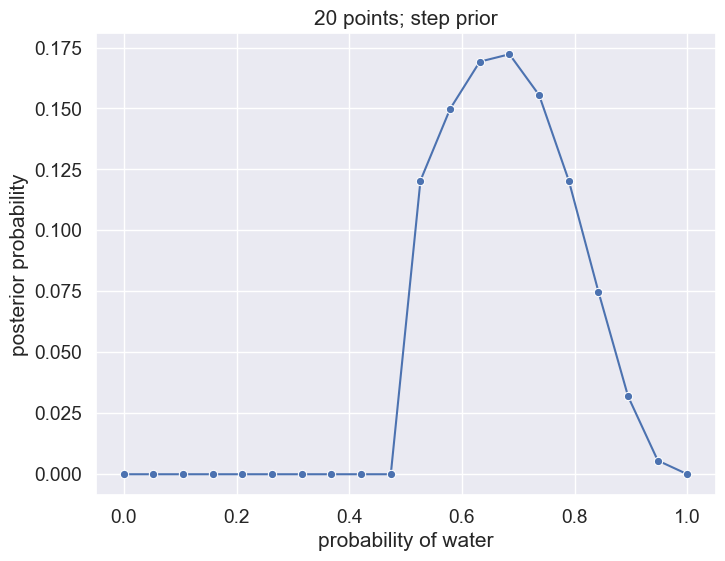

In [11]:
# Code 2.5

prior = torch.where(p_grid < 0.5, torch.tensor(0.), torch.tensor(1.))

likelihood = dist.Binomial(total_count=9, probs=p_grid).log_prob(torch.tensor(6.)).exp()

# Compute product of likelihood and prior
unstd_posterior = likelihood * prior

# standardize the posterior, so it sums to 1
posterior = unstd_posterior / unstd_posterior.sum()

ax = sns.lineplot(x=p_grid, y=posterior, marker="o")
ax.set(xlabel="probability of water", ylabel="posterior probability",
       title="20 points; step prior");

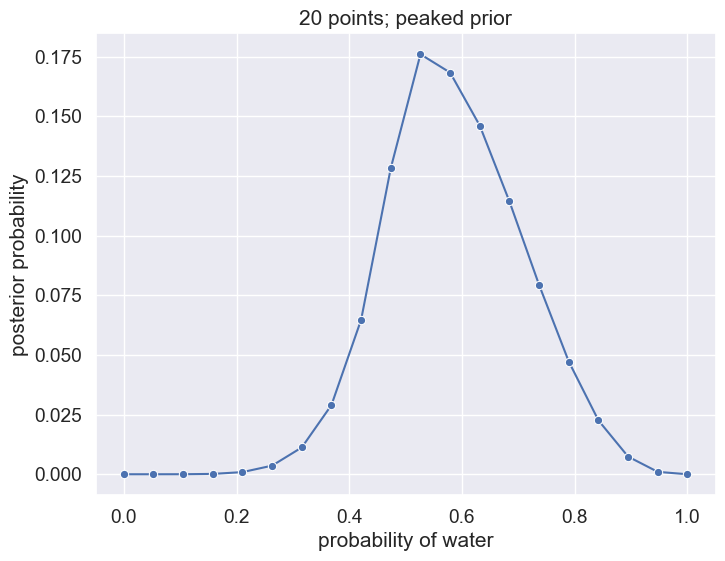

In [12]:
# Code 2.5

prior = (-5 * (p_grid - 0.5).abs()).exp()

likelihood = dist.Binomial(total_count=9, probs=p_grid).log_prob(torch.tensor(6.)).exp()

# Compute product of likelihood and prior
unstd_posterior = likelihood * prior

# standardize the posterior, so it sums to 1
posterior = unstd_posterior / unstd_posterior.sum()

ax = sns.lineplot(x=p_grid, y=posterior, marker="o")
ax.set(xlabel="probability of water", ylabel="posterior probability",
       title="20 points; peaked prior");

Typically grid approximation is not used because it scales very poorly as the number of parameters increases. 

### 2.4.4 Quadratic approximation

Under gener conditions the region near the peak of the posterior distribution will be nearly Gaussian -> leads to **QUADRATIC APPROXIMATION**

Steps in quadratic approximation:

 1. Find the posterior mode. Usually accomplished by some optimization algorithm such as hill climbing or something more clever. 
 2. Estimate the curvature near the peak -> used to copute a quadratic approximation of the entire posterior distribution. 

 Here is an example using quadratic approximation in pyro

In [62]:
# Code 2.6

def model(w):
    p = pyro.sample("p", dist.Uniform(0, 1))
    pyro.sample("w", dist.Binomial(9, p), obs=w)

globe_qa = MAP(model).run(torch.tensor(6.))

# display summary of quadratic approximation
precis(globe_qa)

,Mean,StdDev,|0.89,0.89|
p,0.67,0.13,0.46,0.88


Plot the approximated posterior against the true posterior

In [58]:
precis_df['Mean'].item()

0.59

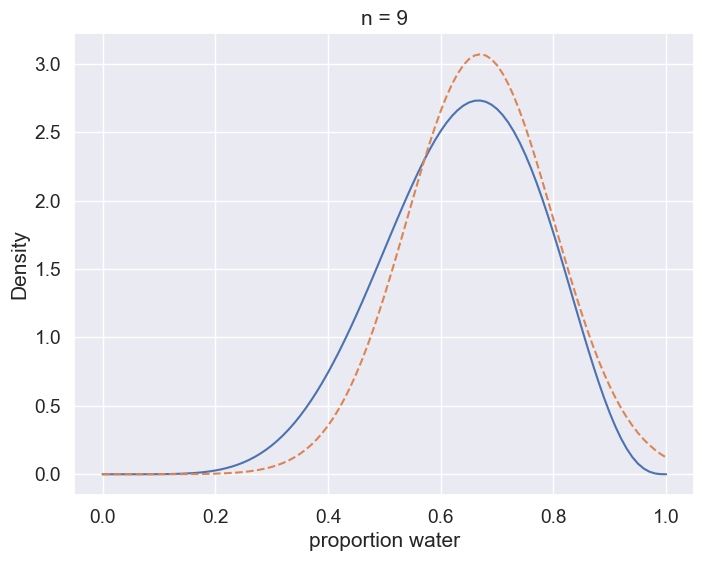

In [63]:
# Code 2.7

# Analytical calculation
w = 6
n = 9
x = torch.linspace(0, 1, 101)
ax = sns.lineplot(x=x, y=dist.Beta(w + 1, n-w + 1).log_prob(x).exp())
ax.set(xlabel="proportion water", ylabel="Density", title="n = 9")

# quadratic approximation
precis_df = precis(globe_qa)
sns.lineplot(x=x, y=dist.Normal(precis_df['Mean'].item(),
                            precis_df['StdDev'].item()).log_prob(x).exp())
ax.lines[1].set_linestyle("--")

The quadratic approximation improves with the amount of data, and is nearly the same as frequentist approaches when using a uniform prior and a lot of data.

### 2.4.5 Markov chain Monte Carlo

For many kinds of complex models, grid approximation and quadratic approximation will simply not work. One commonly used tool is to use **MARKOV CHAIN MONTE CARLO** (MCMC). This method draws samples from the posterior to estimate it. Often in Bayesian analaysis we work with samples rather than directly with the posterior.